# **Technical Note: Ensemble Methods**

## **Business Case Introduction**
**Universal Bank** wants to improve the targeting of its **personal loan marketing campaigns** by identifying customers who are most likely to accept a loan offer. Historical campaigns had a **low acceptance rate**, leading to high marketing costs and low efficiency.

### **Load and Preview Data in R**

In [39]:
import pandas as pd
import numpy as np

# Load Dataset
bank = pd.read_csv("../Datasets/UniversalBank.csv")

In [40]:
# Preview structure
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Experience         5000 non-null   int64  
 3   Income             5000 non-null   int64  
 4   ZIP Code           5000 non-null   int64  
 5   Family             5000 non-null   int64  
 6   CCAvg              5000 non-null   float64
 7   Education          5000 non-null   int64  
 8   Mortgage           5000 non-null   int64  
 9   PersonalLoan       5000 non-null   int64  
 10  SecuritiesAccount  5000 non-null   int64  
 11  CDAccount          5000 non-null   int64  
 12  Online             5000 non-null   int64  
 13  CreditCard         5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### **Step 0: Preprocessing**

In [41]:
bank.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [42]:
# Replace negative Experience values with NA
bank['Experience'] = np.where(bank['Experience'] < 0, np.nan, bank['Experience'])

# Apply median imputation for missing Experience
bank['Experience'] = np.where(bank['Experience'].isna(), bank['Experience'].median(), bank['Experience'])

# Convert 'Education' and 'Family' using explicit level labels
bank['Education'] = pd.Categorical(bank['Education'].map({1:'Undergraduate', 
                                                          2:"Graduate", 
                                                          3:"Advanced"}), 
                                   categories=["Undergraduate", "Graduate", "Advanced"], 
                                   ordered=True)

bank['Family'] = pd.Categorical(bank['Family'].map({1:"Single", 
                                                    2:"Couple", 
                                                    3:"3 members", 
                                                    4:"4+ members"}), 
                                categories=["Single", "Couple", "3 members", "4+ members"], 
                                ordered=True)

# Convert 'PersonalLoan' to a binary variable
bank['PersonalLoan'] = bank['PersonalLoan'].astype("category")

# Drop 'ID' and 'ZIP code' columns (they are not useful for our models)
bank.drop(columns=["ID", "ZIP Code"], axis=1, inplace=True)

bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                5000 non-null   int64   
 1   Experience         5000 non-null   float64 
 2   Income             5000 non-null   int64   
 3   Family             5000 non-null   category
 4   CCAvg              5000 non-null   float64 
 5   Education          5000 non-null   category
 6   Mortgage           5000 non-null   int64   
 7   PersonalLoan       5000 non-null   category
 8   SecuritiesAccount  5000 non-null   int64   
 9   CDAccount          5000 non-null   int64   
 10  Online             5000 non-null   int64   
 11  CreditCard         5000 non-null   int64   
dtypes: category(3), float64(2), int64(7)
memory usage: 366.8 KB


Remenber try not to convert binary variables to category to avoid redundant information

### **Step 1: Exploratory Data Analysis**

In [43]:
# Check the balance of the target variable
bank['PersonalLoan'].value_counts()

PersonalLoan
0    4520
1     480
Name: count, dtype: int64

In [44]:
bank['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

The output reveals a class imbalance in our target variable (`PersonalLoan`). Only **480** accepted a personal loan **(9.6%)** meanwhile **4520 (90.4%)** did not.

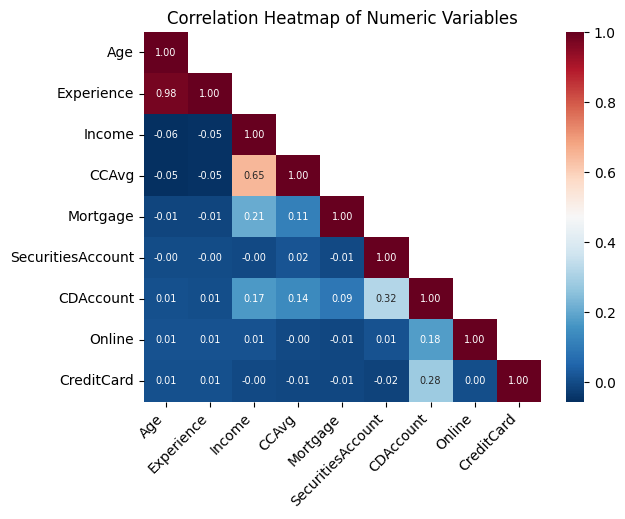

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the numeric variables from the dataset
numeric_vars = bank.select_dtypes("number")

# Plot correlation matrix
cor_numeric_vars = numeric_vars.dropna().corr()
division = np.triu(np.ones_like(cor_numeric_vars, dtype="bool"), k=1) # It helps us visualize the squares 
                                                                        # below the main diagonal
sns.heatmap(cor_numeric_vars,
            mask=division,
            annot=True, # Write the date in each cell
            fmt=".2f", # Adding two decimals
            cmap="RdBu_r",
            annot_kws={'size': 7})
plt.title("Correlation Heatmap of Numeric Variables")
plt.xticks(rotation=45, ha="right")
plt.show()

If you visualizes the correlation, most of the variables don't have a high correlation excepting "Experience"-"Age", "CCAvg"-"Income" and "CDAccount"-"SecuritiesAccount".

### **Step 2: Stratified Train/Test Split**

In [47]:
from sklearn.model_selection import train_test_split

# Create a stratified train-test split (70% train, 30% test)
train, test = train_test_split(bank, test_size=0.3, stratify=bank['PersonalLoan'], random_state=123)

In [48]:
# Check class distribution in the training set
train['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

In [49]:
# Check class distribution in the test set
test['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

### **Step 3: Apply SMOTE to Training Set**
Due to the proportion seen in pur target variable, we need to use SMOTE to address class imbalance.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

# "PersonalLoan" is the target variable and all the other variables as predictors
X_train = train.drop(columns=["PersonalLoan"])
Y_train = train['PersonalLoan']

# Identify the name of the categorical columns from the train data
categorical_columns = X_train.select_dtypes(include=['category','object']).columns
# Names of the numeric columns from the train data
numeric_columns = X_train.select_dtypes(include=['number']).columns

# Create a preprocessor that applies One-hot encoding for the categorical columns
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns), 
                                               ('num', 'passthrough', numeric_columns)])

# Adjust the data train to transform the categorical variables (one-hot). We'll get an array after
# fitting the data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply SMOTE
smote = SMOTE(random_state=123)
X_train_smote, Y_train_smote = smote.fit_resample(X_train_encoded, Y_train)

In [58]:
# Check class balance after applying SMOTE
Y_train_smote.value_counts(normalize=True)

PersonalLoan
0    0.5
1    0.5
Name: proportion, dtype: float64

In [60]:
# For the test set, separate the variables from we'll use to predict values to real values 
X_test = test.drop(columns=['PersonalLoan'])
Y_test = test['PersonalLoan']

# Apply the same transformation for the test set (one-hot for categorical variables), but do not 
# use SMOTE
X_test_processed = preprocessor.fit_transform(X_test)
# Check the real values
Y_test.value_counts(normalize=True)


PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

Comparing to R, in Python you must split your trainning and test data according to your explanatory and the target variable for each, and then keep them in new sections.
In R, you can use your explanatory and target variable together in the same set (trainning and test data).